## EAX - Error Analysis Exercise
## Physics 111B Fall 2026

### Note

All Physics 111 Advanced Lab students are required to complete this assignment at the beginning of the semester. It will be graded on 50 points basis; a late turn-in is allowed only with the instructor's approval before the due date. Don't jeopardize your grade on your first experiment by being late with this assignment. You need to know how to calculate uncertainty in your data before you start a laboratory experiment.

Important: View the <a href="http://youtu.be/jR54387Wd6c">video introduction to error analysis</a> (you need to use your Berkeley email to access this). The Error Analysis Exercise due date is listed on bCourses.

### References

<p><span style="font-size:16px">Reprints and other information can be found on the <a href="https://experimentationlab.berkeley.edu/EAX/">Physics 111 Library Site.</a></span></p>

### Introduction

<p>In the 111-lab, the experiment does not end when you have finished collecting your data. In many labs, you will be required to perform a detailed analysis of the data you have acquired. The point of any scientific experiment is to make quantitative statements about the properties of the physical world. A common question is, are your measurements consistent with a particular theory or not? This question can only be answered by careful analysis, including both systematic uncertainties and statistical error.</p>
<p>The goals of this exercise are twofold. One is to familiarize students with the basics of error analysis. Ideally, this will serve as a guide during the acquisition and analysis of data throughout the advanced lab. The second goal is to introduce students to the Python computing environment, which you will be using throughout the semester.</p>
<p>Before starting on EAX, please look over either the Python Tutorials <a href="https://github.com/avirukt/intro_python">https://github.com/avirukt/intro_python</a> or the<a href="/matlabintro"> </a><a href="/matlabintro" title="Intro to Matlab">Intro to </a><a href="/matlabintro">Matlab</a> section.  Additional resources for using Python are 

 - <a href="http://pythontutor.com/">http://pythontutor.com/</a>  - <a href="https://datahub.berkeley.edu/">https://datahub.berkeley.edu/</a>
 - <a href="https://www.learnpython.org/">Python 3 tutorials</a>
 - <a href="https://www.codecademy.com/learn/learn-python">Free to sign up; introductory Python 2 tutorials (printing is a bit different than Python 3)</a>
 - <a href="https://www.youtube.com/watch?v=rfscVS0vtbw">4.5 hour video covering all the Python basics</a>
 </p>

## Problem Set

### Problem 1: Poisson statistics

We want to measure the activity (number of decays per second, a unit known as Becquerel) of a radioactive source so that we can use it to calibrate the equipment of the gamma-ray experiment. We use an electronic counter and a timer to measure the number of decays in a given time interval. In round numbers we obtain 100,000 decays in 5 minutes. How long does it take (in seconds) in order to determine the activity with a statistical uncertainty of 0.1%? Explain.

Enter the calculation in the cell below. Add a "Markdown" cell to explain your calculation

In [3]:
decays_per_min = 100000 / 5
decays_per_sec = decays_per_min / 60
uncert = 0.001
decays_for_uncert = 1 / (uncert ** 2) # std = sqrt(N), uncert = std/N = 1/sqrt(N)
time = decays_for_uncert / decays_per_sec
time

3000.0

First, I converted the 100k decays per 5 minutes into decays per second. A statistical uncertainty means the standard deviation divided by the number of samples, and since this is a poisson statistic (due to number of measurement), the standard deviation is sqrt(N). From this, the uncertainty can be found to equal sqrt(N), and this is flipped to become N = 1/uncert^2. Then to get time, just do N decays / decays per sec, to get seconds.

### Problem 2: Error propagation

a) You are given the measurements of two variables $A$ and $B$ with the associated errors $\sigma_A$ and $\sigma_B$, respectively. Assuming $A$ and $B$ are uncorrelated, calculate the error in $C$, $\sigma_C$:

 (i) $C = 3A + 5B$

 (ii) $C = A/B$

 (iii) $C = A^B$

 (iv) $C = B \ln A$

b) In the muon lifetime experiment we obtain a histogram for the decay rate as a function of the time after the muon first enters the detector. We expect the distribution (the histogram) to be described by an exponential function. Rather than fitting with an exponential function, it is more convenient to plot the logarithm of the decay rate as a function of time and then fit a straight line to it. Since each data point $(x_i, y_i)$ has a statistical error, $\sigma_{y_i}$, associated with it, what qualitatively happens to the shape of the error bars when the semi-log histogram $(x_i, \log y_i)$ is plotted? Explain and illustrate. Write an equation to describe what happens to the error bars quantitatively under the assumption that $y_i$ is reasonably large.

c) In a separate experiment, you find that $\log_{10} E_0 = 1.5 \pm 0.5$ (at 68% confidence level, CL). What is the value of $E_0$ and the experimental bounds at 68% CL? (Note that 0.5 is not small compared to 1.5).

Write down the calculation in the "Markdown" cell below, or enclose a separate file. Show the details of your calculation.

#### Part A
Since this is in a jupyter notebook, and I am a CS major, I thought it would be better to show my calculations in terms of code rather than LaTeX for part A. I did this by taking partial derivatives, and plugging into the same equation

In [4]:
import math

def f_i(a, b, sig_a, sig_b, ca=3, cb=5):
    da = ca
    db = cb
    return ca*a + cb*b, math.sqrt((da*sig_a)**2 + (db*sig_b)**2)

def f_ii(a, b, sig_a, sig_b):
    da = 1/b
    db = a/(b**2)
    return a/b, math.sqrt((da*sig_a)**2 + (db*sig_b)**2)

def f_iii(a, b, sig_a, sig_b):
    da = b * (a**(b-1))
    db = (a**b)*math.log(a)
    return a**b, math.sqrt((da*sig_a)**2 + (db*sig_b)**2)

def f_iv(a, b, sig_a, sig_b):
    da = b/a
    db = math.log(a)
    return a**b, math.sqrt((da*sig_a)**2 + (db*sig_b)**2)

#### Part B


We know that $\sigma_{y_i} = \sqrt{y_i}$ for a bin

Using error propagation for the semi log, the error is $\sigma_{y_i} / y_i = 1/\sqrt{y_i}$, which is the equation assuming that y is large.

I chose to explain this by showing a random code example, which shows how the error bars change as things are increased

C:\Users\clubb\AppData\Local\Temp\ipykernel_41028\869760495.py:13: RuntimeWarning: divide by zero encountered in log
  log_y = np.log(y)
C:\Users\clubb\AppData\Local\Temp\ipykernel_41028\869760495.py:14: RuntimeWarning: invalid value encountered in divide
  sigma_log_y = sigma_y / y  # calc error, propagated


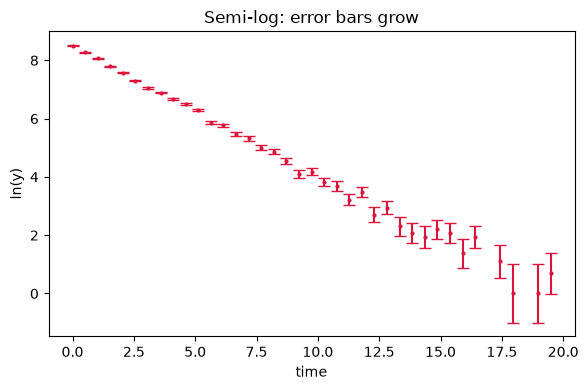

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# constants for example
lifetime = 2.2
N_first = 5000
x = np.linspace(0, 20, 40) # time bins

y_true = N_first * np.exp(-x / lifetime)
y = np.random.poisson(y_true) # add noise for error bars
sigma_y = np.sqrt(y) # calc error

log_y = np.log(y)
sigma_log_y = sigma_y / y  # calc error, propagated

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.errorbar(x, log_y, yerr=sigma_log_y, fmt='o', ms=2, capsize=4, color='crimson')
ax.set_title("Semi-log: error bars grow")
ax.set_xlabel("time")
ax.set_ylabel("ln(y)")

plt.tight_layout()
plt.show()

### Problem 3: Central Limit Theorem

Here we will verify the Central Limit Theorem and reproduce a plot similar to that from Wikipedia (https://en.wikipedia.org/wiki/Central_limit_theorem#/media/File:Dice_sum_central_limit_theorem.svg)

a) Write a function that returns $n$ integer random numbers, uniformly distributed between 1 and 6, inclusively. This represents $n$ throws of a fair 6-sided die. The value that comes up at each throw will be called the "score".

b) Generate a distribution of 10,000 dice throws and plot it as a histogram normalized to unit area. Compute the mean $\mu_1$ and standard deviation $\sigma_1$ of this distribution. Compare your numerical result to the analytical calculation. 

c) Generate 10,000 sets of throws of $N=2, 4, 9, 16, 25, 64$ dice, computing the total sum of dice scores for each set. For each value of $N$, plot the distribution of total scores, and compute the mean $\mu_N$ and standard deviation $\sigma_N$ of each distribution. This should be similar to the plot at the link above.

d) Plot the standard deviation $\sigma_N$ as a function of $N$. Does it follow the Central Limit Theorem? 

### Problem 4: gamma peak

You are given a dataset (peak_F26.dat), in the current directory) from a gamma-ray experiment consisting of ~1000 detections. Each line in the file corresponds to one recorded gamma-ray event and stores the measured energy of the gamma-ray. We will assume that the energies are randomly distributed about a common mean, and that each event is uncorrelated to others. Read the dataset from the enclosed file and:

a) Compute the mean and standard deviation of the given distribution of measured energies. These are estimates of the mean and standard deviation of the underlying parent distribution. Determine the uncertainties for these estimates of the mean and variance of the parent distribution. (Hint: The fractional uncertainty in the estimate of the standard deviation for Gaussian distributed data is given by Equation 2.8 in Reference 4, I. G. Hughes and T. P. A. Hase, "Measurements and their Uncertainties". For the purposes of this calculation, you can assume the sample data is drawn from a Gaussian distribution).

b) Fit the distribution to a Gaussian function using an unbinned fit (<i>Hint:</i> use <tt>scipi.stats.norm.fit()</tt> function), and compare the parameters of the fitted Gaussian with the mean and standard deviation computed in (a). 

c) Produce a histogram of the distribution of energies. Choose the number of bins wisely, i.e. so that the width of each bin is smaller than the width of the peak, and at the same time so that the number of entries in the most populated bin is relatively large. Plot error bars on this histogram representing the uncertainty on the number of counts in each bin. These will serve as the weights for the bins in fits to this distribution.

d) Overplot the binned histogram (including bin error bars) with the best-fit Gaussian function from part (b).

e) Fit the binned distribution to a Gaussian function using a binned least-squares fit (Hint: use <tt>scipy.optimize.curve_fit()</tt> and compare the parameters of the fitted Gaussian and their uncertainties to the parameters obtained in the unbinned fit in part (a).

f) How consistent is the binned distribution with a Gaussian? In other words, compare the binned histogram from part (c) to the best-fit Gaussian parameters from both the unbinned and binned fits in parts (b) and (e) and compute a goodness-of-fit value, such as $\chi^2/\mathrm{dof}$, for each of the fits.

### Problem 5: Optical Pumping

In the optical pumping experiment (OPT), we measure the resonant frequency of a Zeeman transition as a function of the applied current (proportional to the applied magnetic field). This exercise is identical to the analysis that you will need to perform for OPT. Consider a mock data set:

\[
\begin{array}{c|cccccccccccc}
I\ (\mathrm{A}) & 0.0 & 0.2 & 0.4 & 0.6 & 0.8 & 1.0 & 1.2 & 1.4 & 1.6 & 1.8 & 2.0 & 2.2 \\
\hline
f\ (\mathrm{MHz}) & 0.069 & 0.719 & 1.42 & 2.08 & 2.93 & 3.5 & 4.33 & 4.92 & 5.94 & 6.19 & 7.26 & 7.69
\end{array}
\]

a) Plot a graph of the pairs of values. Assuming a linear relationship between $I$ and $f$, determine the slope and the intercept of the best-fit line using the least-squares method with equal weights, and draw the best-fit line through the data points on the graph.

b) From what they know about the equipment used to measure the resonant frequency, your lab partner hastily estimates the uncertainty in the measurement of $f$ to be $\sigma_f = 0.02\,\mathrm{MHz}$. Estimate the probability that the straight line you found is an adequate description of the observed data if it is distributed about this line with the uncertainty guessed by your lab partner. (Hint: use $\texttt{scipy.stats.chi2}$ class to compute the quantile of the $\chi^2$ distribution). What can you conclude from these results?

c) As in the case of part (b), we do not always have accurate a-priori estimates of the uncertainty in the data. When the data is consistent with statistical scatter about a known model, an estimate of the uncertainty in the measurements can be determined from the scatter of the data about the best fit model. Assume that the data is perfectly described by uniform statistical scatter about a linear model. Estimate the uncertainty $\sigma_f$ in the measurement of $f$ from the scatter of the data about the best-fit line. Assume that all the data points have equal weight. Use this new value for $\sigma_f$ to estimate the uncertainty in both the slope and the intercept of the best-fit line. This is the technique you will use in the Optical Pumping lab to determine the uncertainties in the fit parameters. This is valid only in the limit where the model is a good fit to the data and the scatter about the model is purely statistical with no additional systematic errors.

d) Now assume that the uncertainty in each value of $f$ grows with increasing $f$ as:
$\sigma_f = 0.1\,\mathrm{MHz} + 0.1\,f$.
Determine the slope and the intercept of the best-fit line using the least-squares method with these weights (weighted least-squares fit). What are the values and uncertainties for the slope and intercept? Do they differ significantly from those found for the unweighted fit? What is the resulting $\chi^2$ for the weighted linear fit?

e) Here we again use the data to inform the estimate of uncertainty. Assume that a line is a good fit to the data and that the actual measurement errors are a scaled version of the function given in part (d) such that the reduced $\chi^2 = 1$ for the fit of the data to the linear model. With these assumptions, revise the estimate of uncertainties in the slope and offset of the linear fit. Plot the data with the best-fit line and scaled uncertainties.